In [36]:
import os
import pandas as pd
from pymongo import MongoClient
from pymongo.server_api import ServerApi

def concat_csvs_from_folder(folder_path):
    all_dfs = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder_path, filename)
            try:
                df = pd.read_csv(file_path)
                all_dfs.append(df)
                print(f"✅ Loaded {filename} ({len(df)} rows)")
            except Exception as e:
                print(f"⚠️ Failed to read {filename}: {e}")

    if not all_dfs:
        raise ValueError("No valid CSVs found in folder")

    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n📊 Combined {len(all_dfs)} CSVs → {len(combined_df)} total rows")
    return combined_df

# Example usage
folder_path = "backtest_results"
big_df = concat_csvs_from_folder(folder_path)


✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-25.csv (291 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-19.csv (259 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-18.csv (259 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-24.csv (288 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-26.csv (369 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-27.csv (293 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-23.csv (271 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-22.csv (291 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-08.csv (246 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-20.csv (259 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-21.csv (285 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-02-09.csv (305 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-12.csv (271 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-06.csv (339 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-0

In [4]:
big_df

,player_name,player_id,bet_type,over_prob,under_prob,adj_over_prob,adj_under_prob,over_odds,under_odds,line,...,overKellyStake,underKellyStake,overEV,underEV,bankroll,gameId,dateStart,lineTime,calculatedAt,profit
0,Austin Reaves,2845,player_assists,0.48,0.57,0.50,0.51,124,-160,5.5,...,91.85,0.00,10.46,-0.00,1000,14949,2025-02-26T03:00:00Z,2025-02-26T02:54:57Z,2025-10-10T13:28:23.120455,-91.85
1,Kyrie Irving,261,player_assists,0.63,0.33,0.52,0.48,-166,130,4.5,...,0.00,78.77,-0.00,8.07,1000,14949,2025-02-26T03:00:00Z,2025-02-26T02:54:57Z,2025-10-10T13:28:23.124717,102.41
2,Dante Exum,164,player_assists,0.48,0.61,0.50,0.51,130,-166,3.5,...,110.56,0.00,15.89,-0.00,1000,14949,2025-02-26T03:00:00Z,2025-02-26T02:54:57Z,2025-10-10T13:28:23.128857,-110.56
3,Naji Marshall,2668,player_assists,0.40,0.65,0.49,0.52,110,-140,2.5,...,21.43,0.00,0.51,-0.00,1000,14949,2025-02-26T03:00:00Z,2025-02-26T02:54:57Z,2025-10-10T13:28:23.142022,23.57
4,Naji Marshall,2668,player_points,0.43,0.57,0.50,0.50,114,-145,11.5,...,56.09,0.00,3.59,-0.00,1000,14949,2025-02-26T03:00:00Z,2025-02-26T02:54:57Z,2025-10-10T13:28:23.182368,-56.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29876,Ochai Agbaji,3411,player_threes,0.53,0.41,0.50,0.49,-220,170,0.5,...,0.00,182.46,-0.00,56.60,1000,14914,2025-02-22T00:40:00Z,2025-02-22T00:34:05Z,2025-10-10T11:04:56.792924,310.19
29877,Davion Mitchell,2834,player_threes,0.53,0.41,0.50,0.49,-188,145,0.5,...,0.00,130.26,-0.00,24.60,1000,14914,2025-02-22T00:40:00Z,2025-02-22T00:34:05Z,2025-10-10T11:04:56.797237,-130.26
29878,Kel'el Ware,4138,player_threes,0.53,0.34,0.50,0.47,-175,135,0.5,...,0.00,80.28,-0.00,8.70,1000,14914,2025-02-22T00:40:00Z,2025-02-22T00:34:05Z,2025-10-10T11:04:56.801423,108.38
29879,Ja'Kobe Walter,4177,player_threes,0.53,0.41,0.50,0.49,-154,120,0.5,...,0.00,56.30,-0.00,3.80,1000,14914,2025-02-22T00:40:00Z,2025-02-22T00:34:05Z,2025-10-10T11:04:56.805627,-56.30


In [5]:
def deduplicate_by_latest_line_time(df):
    # Ensure lineTime is parsed as datetime
    df['lineTime'] = pd.to_datetime(df['lineTime'], errors='coerce')

    # Sort by lineTime descending so latest entries come first
    df_sorted = df.sort_values('lineTime', ascending=False)

    # Drop duplicates keeping only the most recent for each player_id + bet_type + gameId combo
    df_unique = df_sorted.drop_duplicates(
        subset=['player_id', 'bet_type', 'gameId'], keep='first'
    )

    print(f"✅ Reduced from {len(df)} → {len(df_unique)} unique rows")
    return df_unique.reset_index(drop=True)

In [6]:
deduped_df = deduplicate_by_latest_line_time(big_df)

✅ Reduced from 29881 → 13642 unique rows


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_daily_profit(df, bet_type_filter=None, ev_top_n=10):
    """
    Plot daily profit, cumulative profit, and hit rate (with cumulative average).
    Optionally filter by bet type(s) and limit to top-N EV bets per day.

    Args:
        df (pd.DataFrame): Must include columns:
            ['dateStart','profit','bet_type','overKellyStake','underKellyStake','overEV','underEV']
        bet_type_filter (str | list[str] | None): Optional bet type filter.
        ev_top_n (int | None): Keep top-N EV bets per day (default 10). None disables filtering.

    Returns:
        pd.DataFrame: daily summary with profit, cumulative profit, hit rate, and cumulative average hit rate.
    """

    required_cols = {
        "dateStart", "profit", "bet_type", 
        "overKellyStake", "underKellyStake", "overEV", "underEV"
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    data = df.copy()

    # ---- Filter by bet type ----
    if bet_type_filter:
        if isinstance(bet_type_filter, str):
            data = data[data["bet_type"] == bet_type_filter]
        elif isinstance(bet_type_filter, (list, tuple, set)):
            data = data[data["bet_type"].isin(bet_type_filter)]
        else:
            raise ValueError("bet_type_filter must be a string or list/tuple/set of strings")

    if data.empty:
        print("⚠️ No rows after filtering by bet type.")
        return pd.DataFrame()

    # ---- Prepare date ----
    data["dateStart"] = pd.to_datetime(data["dateStart"], errors="coerce")
    data = data.dropna(subset=["dateStart"])
    data["date"] = data["dateStart"].dt.date

    # ---- Determine which EV and bet side was taken ----
    data["chosen_EV"] = np.where(data["overKellyStake"] > 0, data["overEV"], data["underEV"])
    data["won"] = np.where(data["profit"] > 0, 1, 0)

    # ---- EV cutoff ----
    if ev_top_n and ev_top_n > 0:
        data = (
            data.sort_values(["date", "chosen_EV"], ascending=[True, False])
                .groupby("date", as_index=False, group_keys=True)
                .head(ev_top_n)
        )

    if data.empty:
        print("⚠️ No rows after applying EV cutoff.")
        return pd.DataFrame()

    # ---- Aggregate ----
    daily_summary = (
        data.groupby("date")
        .agg(
            profit=("profit", "sum"),
            bets=("won", "count"),
            hits=("won", "sum")
        )
        .reset_index()
        .sort_values("date")
    )

    daily_summary["hit_rate"] = daily_summary["hits"] / daily_summary["bets"]
    daily_summary["cumulative_profit"] = daily_summary["profit"].cumsum()

    # ---- NEW: cumulative average hit rate ----
    cumulative_hits = daily_summary["hits"].cumsum()
    cumulative_bets = daily_summary["bets"].cumsum()
    daily_summary["cumulative_hit_rate"] = cumulative_hits / cumulative_bets

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Left axis → profit
    ax1.plot(daily_summary["date"], daily_summary["profit"], marker="o", label="Daily Profit", color="tab:blue")
    ax1.plot(daily_summary["date"], daily_summary["cumulative_profit"], linestyle="--", label="Cumulative Profit", color="tab:orange")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Profit ($)")
    ax1.grid(True, which="major", axis="both")

    # Right axis → hit rates
    ax2 = ax1.twinx()
    ax2.plot(daily_summary["date"], daily_summary["hit_rate"], marker="s", label="Daily Hit Rate", color="tab:green", alpha=0.6)
    ax2.plot(daily_summary["date"], daily_summary["cumulative_hit_rate"], marker="D", linestyle=":", label="Cumulative Hit Rate", color="tab:red", alpha=0.9)
    ax2.set_ylabel("Hit Rate (%)")
    ax2.set_ylim(0, 1.05)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    # Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    # Title
    bt_label = (
        "All Bet Types" if not bet_type_filter
        else (bet_type_filter if isinstance(bet_type_filter, str) else ", ".join(map(str, bet_type_filter)))
    )
    ev_label = f"Top {ev_top_n} EV/Day" if ev_top_n and ev_top_n > 0 else "No EV Cutoff"
    plt.title(f"Daily Profit & Hit Rate — {bt_label} — {ev_label}")

    plt.tight_layout()
    plt.show()

    return daily_summary


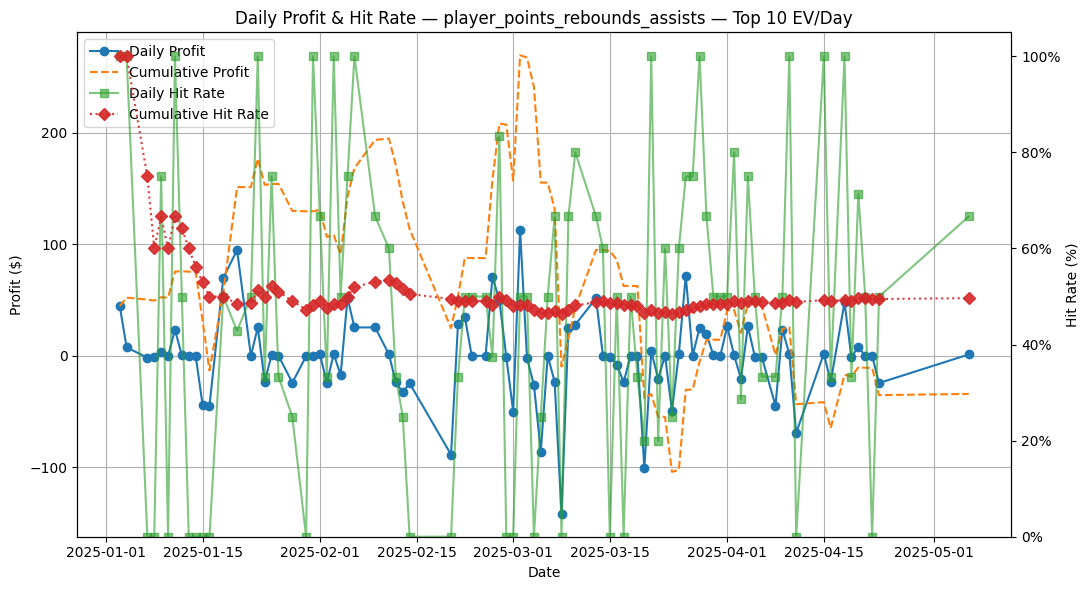

In [8]:
profit_df = plot_daily_profit(deduped_df, 'player_points_rebounds_assists', 10)

In [9]:
profit_df['profit'].sum()

np.float64(-34.19999999999996)

In [10]:
def rank_bet_type_performance(results: pd.DataFrame) -> pd.DataFrame:
    """
    Ranks each bet_type by hit_rate, cumulative_profit, and cumulative_hit_rate.

    Expects columns:
      - 'bet_type'
      - 'profit'  (numeric; >0 means the bet won)
      - (optional) anything else; not used here

    Returns a DataFrame with per-bet_type metrics and ranks.
    """
    required = {"bet_type", "profit"}
    missing = required - set(results.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = results.copy()

    # Win indicator
    df["won"] = (df["profit"] > 0).astype(int)

    # Aggregate per bet_type
    perf = (
        df.groupby("bet_type", as_index=False)
          .agg(
              bets=("won", "count"),
              hits=("won", "sum"),
              cumulative_profit=("profit", "sum"),
          )
    )

    # Metrics
    perf["hit_rate"] = perf["hits"] / perf["bets"]
    # cumulative_hit_rate across the whole period per bet_type == hit_rate
    perf["cumulative_hit_rate"] = perf["hit_rate"]

    # Ranks (higher is better → descending False)
    perf["hit_rate_rank"] = perf["hit_rate"].rank(ascending=False, method="min").astype(int)
    perf["cumulative_profit_rank"] = perf["cumulative_profit"].rank(ascending=False, method="min").astype(int)
    perf["cumulative_hit_rate_rank"] = perf["cumulative_hit_rate"].rank(ascending=False, method="min").astype(int)

    # Optional overall score/rank (sum of ranks; lower = better)
    perf["overall_rank_score"] = (
        perf["hit_rate_rank"] + perf["cumulative_profit_rank"] + perf["cumulative_hit_rate_rank"]
    )
    perf = perf.sort_values(["overall_rank_score", "cumulative_profit"], ascending=[True, False]).reset_index(drop=True)

    # Nice ordering of columns
    cols = [
        "bet_type", "bets", "hits",
        "hit_rate", "cumulative_profit", "cumulative_hit_rate",
        "hit_rate_rank", "cumulative_profit_rank", "cumulative_hit_rate_rank",
        "overall_rank_score",
    ]
    return perf[cols]

In [13]:
deduped_df_copy = deduped_df.copy()
deduped_df_copy["dateStart"] = pd.to_datetime(deduped_df_copy["dateStart"], errors="coerce")
deduped_df_copy = deduped_df_copy.dropna(subset=["dateStart"])
deduped_df_copy["date"] = deduped_df_copy["dateStart"].dt.date


In [29]:
records = deduped_df_copy.to_dict(orient="records")

In [32]:
date_map = {}

for record in records:
    date_str = str(record['date'])
    if date_str in date_map:
        date_map[date_str].append(record)
    else: 
        date_map[date_str] = [record]

In [27]:
date_map

{datetime.date(2025, 5, 6): [{'player_name': 'Isaiah Joe',
   'player_id': 2604,
   'bet_type': 'player_rebounds',
   'over_prob': 1.0,
   'under_prob': 0.37,
   'adj_over_prob': 0.57,
   'adj_under_prob': 0.48,
   'over_odds': -154,
   'under_odds': 120,
   'line': 1.5,
   'teamName': 'Oklahoma City Thunder',
   'teamId': 25,
   'opponentTeamName': 'Denver Nuggets',
   'overKellyStake': 0.0,
   'underKellyStake': 51.93,
   'overEV': -0.0,
   'underEV': 3.24,
   'bankroll': 1000,
   'gameId': 15423,
   'dateStart': Timestamp('2025-05-06 01:35:00+0000', tz='UTC'),
   'lineTime': Timestamp('2025-05-06 01:28:51+0000', tz='UTC'),
   'calculatedAt': '2025-10-09T20:58:06.392972',
   'profit': 62.32,
   'date': datetime.date(2025, 5, 6)}],
 datetime.date(2025, 4, 23): [{'player_name': 'Jaden McDaniels',
   'player_id': 2621,
   'bet_type': 'player_points_rebounds_assists',
   'over_prob': 0.49,
   'under_prob': 0.47,
   'adj_over_prob': 0.5,
   'adj_under_prob': 0.5,
   'over_odds': 100,
   '

In [56]:
from datetime import datetime, date

uri = os.getenv('SBS_V1_MONGO_URI')

client = MongoClient(uri, server_api=ServerApi('1'))
db = client['SBSV1']


bet_reports_collection = db['bet_reports']

def normalize_dates(obj):
    """Recursively convert all datetime.date objects to datetime.datetime."""
    if isinstance(obj, list):
        return [normalize_dates(v) for v in obj]
    elif isinstance(obj, dict):
        return {k: normalize_dates(v) for k, v in obj.items()}
    elif isinstance(obj, date) and not isinstance(obj, datetime):
        return datetime(obj.year, obj.month, obj.day)
    else:
        return obj


sport = 'nba';
mongo_docs = []
for key, val in date_map.items():
    doc = dict()
    id_string = f"{sport}_{str(key)}"
    doc['_id'] = id_string
    doc['date'] = key
    doc['bet_reports'] = val
    doc = normalize_dates(doc)
    # Define your filter (which doc to match)
    filter_doc = { '_id': id_string }
    

    # Perform the upsert (update if exists, insert if not)
    bet_reports_collection.replace_one(filter_doc, doc, upsert=True)
    
